## Setup

In [2]:
#data and visuals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#modelling
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [30]:
#independent data
acxiom = pd.read_csv("../../data/bain_acxiom_master_full.csv").rename(columns={"surveygroupid": "sequence"})


#dependent data
email_survey_responses = pd.read_csv("../../raw/email_survey_responses.csv").rename(columns={"Respondent": "sequence"})

In [32]:
acxiom.head()

,sequence,person_basicdemographics_age,person_basicdemographics_deceased,person_basicdemographics_enteringadulthood,person_basicdemographics_lengthofresidence,person_basicdemographics_singleparent,household_basicdemographics_africanamericanprofessionals,household_basicdemographics_childnearhsgraduation,household_basicdemographics_childrenpresent,household_basicdemographics_estimatedincomemin,...,shoppingandpurchasechannel_mailorderbuyercategories.Art & antiques,shoppingandpurchasechannel_mailorderbuyercategories.Outdoor/Hunting & fishing,shoppingandpurchasechannel_mailorderbuyercategories.Beauty,shoppingandpurchasechannel_mailorderbuyercategories.High ticket merchandise,shoppingandpurchasechannel_mailorderbuyercategories.Travel,shoppingandpurchasechannel_mailorderbuyercategories.Food,shoppingandpurchasechannel_mailorderbuyercategories.Jewelry,shoppingandpurchasechannel_mailorderbuyercategories.Auto supplies,shoppingandpurchasechannel_mailorderbuyercategories.Art & crafts,shoppingandpurchasechannel_mailorderbuyercategories.General gifts and merchandise
0,495554.0,60.0,False,False,15.0,True,False,False,True,125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,494177.0,32.0,False,False,7.0,True,False,False,True,75000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,495191.0,56.0,False,False,15.0,False,False,False,False,125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,494586.0,44.0,False,False,10.0,True,False,False,True,50000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,494841.0,36.0,False,False,1.0,False,False,False,False,50000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
email_survey_responses.head()

,sequence,Assigned Segment,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,Cheap + Comfy,Cheap + Curious,Curious,Comfy,Craver,Caviar
0,496367,Curious,1,5,3,3,5,2,1,1,3,2,35.65,35.19,36.79,33.97,24.88,28.91
1,496360,Comfy,3,3,3,3,4,4,2,4,2,3,52.12,46.99,51.69,53.22,46.62,45.48
2,496350,Caviar,5,5,5,5,5,1,5,1,5,5,76.74,73.22,96.91,96.50,107.86,109.61
3,496339,Cheap + Comfy,2,3,2,3,4,4,2,3,3,4,48.33,46.10,47.23,46.41,38.38,37.37
4,496333,Curious,3,5,3,2,5,3,2,3,3,4,56.68,58.24,61.83,57.45,53.95,53.01


In [35]:
#Enrich and count
email_survey_responses['email_survey_responses'] = "email_survey_responses"
acxiom['acxiom_add'] = "acxiom_add"
print("Shape of email_survey_responses:", email_survey_responses.shape)
print("Shape of acxiom_add:", acxiom.shape)

#Outer join
master = pd.merge(email_survey_responses, acxiom, on = "sequence", how = "outer")
print("Shape of master (after outer join):", master.shape)
print(master[["email_survey_responses","acxiom_add","sequence"]].fillna("none").groupby(
    ["email_survey_responses","acxiom_add"]).agg(['count']))


#Inner join (training set)
master = pd.merge(email_survey_responses, acxiom, on = "sequence", how = "inner")
print("shape of master (after inner join):", master.shape)

#Clean master
master = master.drop(["email_survey_responses","acxiom_add"], axis = 1)
master.head()

Shape of email_survey_responses: (1145, 19)
Shape of acxiom_add: (722, 948)
Shape of master (after outer join): (1255, 966)
                                  sequence
                                     count
email_survey_responses acxiom_add         
email_survey_responses acxiom_add      612
                       none            533
none                   acxiom_add      110
shape of master (after inner join): (612, 966)


,sequence,Assigned Segment,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,...,shoppingandpurchasechannel_mailorderbuyercategories.Art & antiques,shoppingandpurchasechannel_mailorderbuyercategories.Outdoor/Hunting & fishing,shoppingandpurchasechannel_mailorderbuyercategories.Beauty,shoppingandpurchasechannel_mailorderbuyercategories.High ticket merchandise,shoppingandpurchasechannel_mailorderbuyercategories.Travel,shoppingandpurchasechannel_mailorderbuyercategories.Food,shoppingandpurchasechannel_mailorderbuyercategories.Jewelry,shoppingandpurchasechannel_mailorderbuyercategories.Auto supplies,shoppingandpurchasechannel_mailorderbuyercategories.Art & crafts,shoppingandpurchasechannel_mailorderbuyercategories.General gifts and merchandise
0,496350,Caviar,5,5,5,5,5,1,5,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,496339,Cheap + Comfy,2,3,2,3,4,4,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,496333,Curious,3,5,3,2,5,3,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,496332,Caviar,3,3,3,3,4,1,4,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,496028,Caviar,4,1,5,5,2,1,5,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model Setup

In [36]:
#dependent set
dep_master = master[acxiom.columns[acxiom.columns.isin(master.columns)]]
dep_master.head()

,sequence,person_basicdemographics_age,person_basicdemographics_deceased,person_basicdemographics_enteringadulthood,person_basicdemographics_lengthofresidence,person_basicdemographics_singleparent,household_basicdemographics_africanamericanprofessionals,household_basicdemographics_childnearhsgraduation,household_basicdemographics_childrenpresent,household_basicdemographics_estimatedincomemin,...,shoppingandpurchasechannel_mailorderbuyercategories.Art & antiques,shoppingandpurchasechannel_mailorderbuyercategories.Outdoor/Hunting & fishing,shoppingandpurchasechannel_mailorderbuyercategories.Beauty,shoppingandpurchasechannel_mailorderbuyercategories.High ticket merchandise,shoppingandpurchasechannel_mailorderbuyercategories.Travel,shoppingandpurchasechannel_mailorderbuyercategories.Food,shoppingandpurchasechannel_mailorderbuyercategories.Jewelry,shoppingandpurchasechannel_mailorderbuyercategories.Auto supplies,shoppingandpurchasechannel_mailorderbuyercategories.Art & crafts,shoppingandpurchasechannel_mailorderbuyercategories.General gifts and merchandise
0,496350,36.0,False,False,0.0,False,False,False,False,15000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,496339,54.0,False,False,10.0,True,False,False,True,50000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,496333,72.0,False,False,15.0,False,False,False,False,125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,496332,66.0,False,False,15.0,False,False,False,False,75000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,496028,0.0,False,False,2.0,False,False,False,False,125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
#independent set
indep_master = master[email_survey_responses.columns[email_survey_responses.columns.isin(master.columns)]]
indep_master.head()

,sequence,Assigned Segment,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,Cheap + Comfy,Cheap + Curious,Curious,Comfy,Craver,Caviar
0,496350,Caviar,5,5,5,5,5,1,5,1,5,5,76.74,73.22,96.91,96.50,107.86,109.61
1,496339,Cheap + Comfy,2,3,2,3,4,4,2,3,3,4,48.33,46.10,47.23,46.41,38.38,37.37
2,496333,Curious,3,5,3,2,5,3,2,3,3,4,56.68,58.24,61.83,57.45,53.95,53.01
3,496332,Caviar,3,3,3,3,4,1,4,1,5,3,45.18,39.71,51.36,52.75,48.79,54.34
4,496028,Caviar,4,1,5,5,2,1,5,1,4,1,41.21,22.25,46.04,58.35,54.87,64.14


Caviar             233
Craver             161
Curious            110
Comfy               66
Cheap + Curious     26
Cheap + Comfy       16
Name: Assigned Segment, dtype: int64


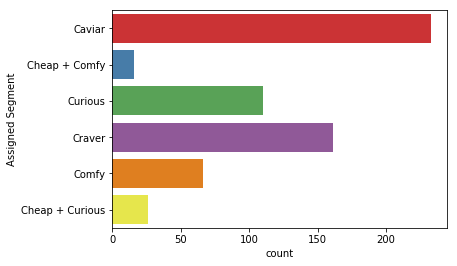

4    226
5    163
3    157
2     46
1     20
Name: I always choose higher end hotels, dtype: int64


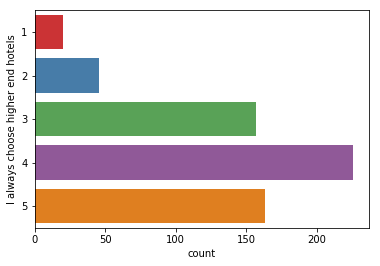

5    295
4    186
3    108
2     16
1      7
Name: On vacation I pride myself on discovering new places and things my friends have not seen before, dtype: int64


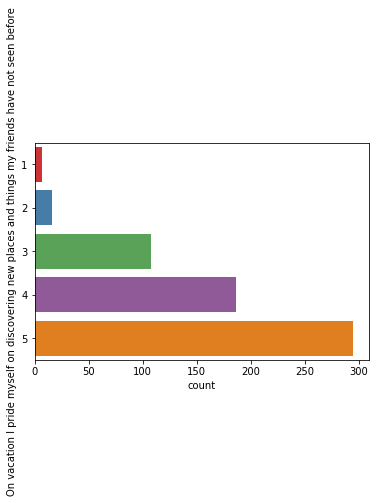

4    205
5    190
3    153
2     46
1     18
Name: I choose more expensive hotels and accommodations to make sure I get the best service and amenities, dtype: int64


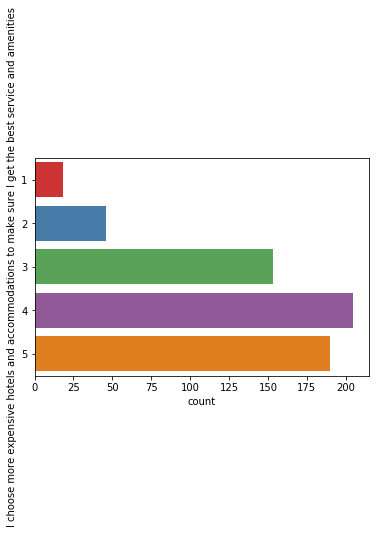

5    238
4    180
3    145
2     35
1     14
Name: It is important for me to be in a luxurious setting and to be pampered on vacation, dtype: int64


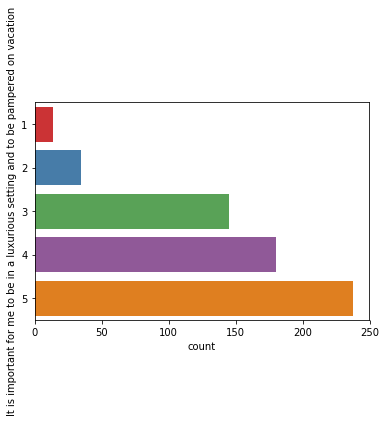

5    264
4    175
3    146
2     22
1      5
Name: I like to immerse myself in the local culture when on vacation, dtype: int64


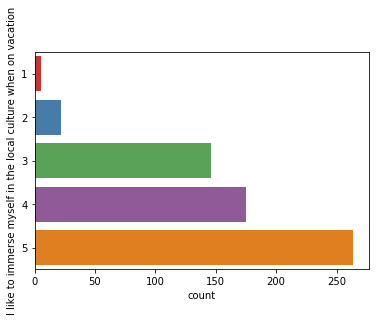

3    178
2    168
4    114
1    105
5     47
Name: The difference between luxury and standard hotels just is not big enough to justify the cost, dtype: int64


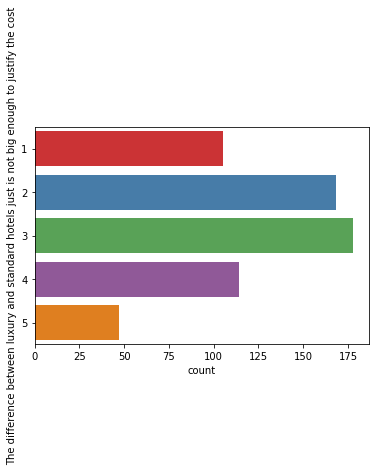

3    190
4    185
2    104
5    103
1     30
Name: I always pay more for a higher class of room on my vacations, dtype: int64


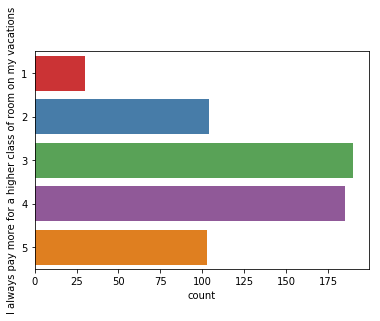

3    178
2    163
1    124
4    102
5     45
Name: I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation, dtype: int64


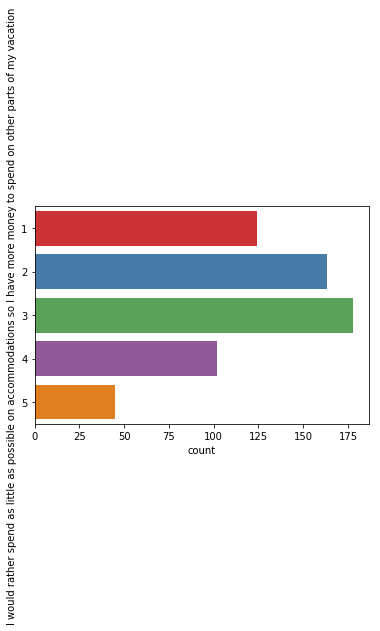

4    240
5    228
3    107
2     26
1     11
Name: I think spending more for unique experiences is part of what makes a vacation special, dtype: int64


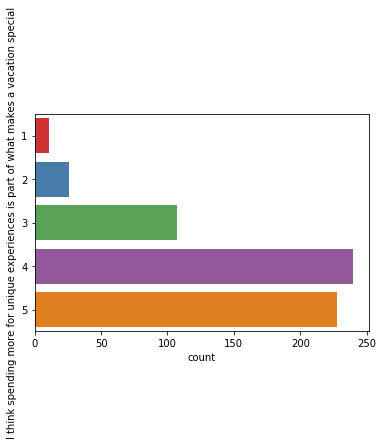

4    202
3    198
5    143
2     58
1     11
Name: I like to go on vacations that are off the beaten path, dtype: int64


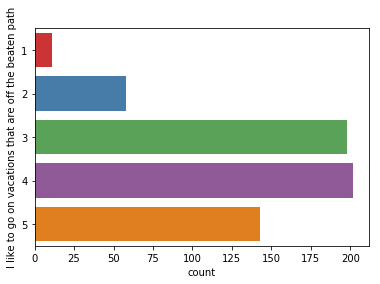

In [38]:
def categorical_summarized(dataframe, x=None, y=None, hue=None, palette='Set1', verbose=True):
    if x == None:
        column_interested = y
    else:
        column_interested = x
    series = dataframe[column_interested]
    if verbose:
        print('='*80)
        print(series.value_counts())

    sns.countplot(x=x, y=y, hue=hue, data=dataframe, palette=palette)
    plt.show()
    
for i in indep_master.columns[~indep_master.columns.isin(indep_master['Assigned Segment'].values) &
                             ~indep_master.columns.isin(['sequence'])]:
    categorical_summarized(indep_master, y = i)

In [63]:
#train/test split
x_train, x_test, y_train, y_test = train_test_split(dep_master.drop(['sequence'], axis = 1), 
                                                    indep_master.drop(
                                                        ['sequence'], axis = 1), test_size=0.2, random_state=0)

x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_test.mean())
print("Shape - x_train:",x_train.shape)
print("Shape - x_test:",x_test.shape)
print("Shape - y_train:",y_train.shape)
print("Shape - y_test:",y_test.shape)

Shape - x_train: (489, 946)
Shape - x_test: (123, 946)
Shape - y_train: (489, 17)
Shape - y_test: (123, 17)


### 1. Baseline: Directly predicting segments

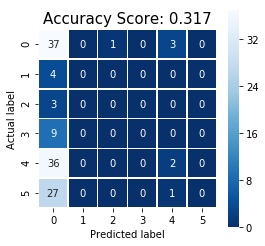

In [64]:
#model
# all parameters not specified are set to their defaults
logisticRegr = LogisticRegression(random_state=0)
logisticRegr.fit(x_train, y_train['Assigned Segment'])
predictions = logisticRegr.predict(x_test)
# Use score method to get accuracy of model
score = logisticRegr.score(x_test, y_test['Assigned Segment'])

cm = metrics.confusion_matrix(y_test['Assigned Segment'], predictions)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

In [86]:
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
import numpy as np

tpot = TPOTClassifier(generations=5, population_size=50, verbosity=2, scoring = 'f1_weighted')
tpot.fit(x_train, y_train['Assigned Segment'])

Generation 1 - Current best internal CV score: 0.2892281429225968
Generation 2 - Current best internal CV score: 0.29454573153580366
Generation 3 - Current best internal CV score: 0.29588173641717846
Generation 4 - Current best internal CV score: 0.3076669569823153
Generation 5 - Current best internal CV score: 0.3252135351572056

Best pipeline: GradientBoostingClassifier(CombineDFs(input_matrix, input_matrix), learning_rate=0.5, max_depth=4, max_features=0.15000000000000002, min_samples_leaf=10, min_samples_split=7, n_estimators=100, subsample=0.9500000000000001)


TPOTClassifier(config_dict=None, crossover_rate=0.1, cv=5,
        disable_update_check=False, early_stop=None, generations=5,
        max_eval_time_mins=5, max_time_mins=None, memory=None,
        mutation_rate=0.9, n_jobs=1, offspring_size=None,
        periodic_checkpoint_folder=None, population_size=50,
        random_state=None, scoring='f1_weighted', subsample=1.0,
        template='RandomTree', use_dask=False, verbosity=2,
        warm_start=False)

In [87]:
tpot.export('tpot_direct_assigned_segment_f1.py')

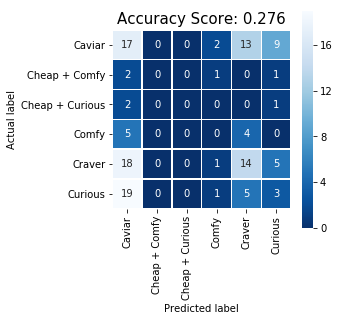

In [103]:
#optimized for weighted f1

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, make_union
from tpot.builtins import StackingEstimator
from sklearn.preprocessing import FunctionTransformer
from copy import copy

exported_pipeline = make_pipeline(
    make_union(
        FunctionTransformer(copy),
        FunctionTransformer(copy)
    ),
    GradientBoostingClassifier(learning_rate=0.5, max_depth=4, max_features=0.15000000000000002, min_samples_leaf=10, min_samples_split=7, n_estimators=100, subsample=0.9500000000000001)
)

exported_pipeline.fit(x_train, y_train['Assigned Segment'])
predictions = exported_pipeline.predict(x_test)

score = exported_pipeline.score(x_test, y_test['Assigned Segment'])
cm = metrics.confusion_matrix(y_test['Assigned Segment'], predictions)
plt.figure(figsize=(4,4))
ax = sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r'
                ,xticklabels = exported_pipeline.classes_, yticklabels = exported_pipeline.classes_
                );
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

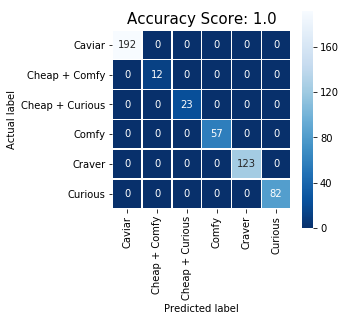

In [104]:
predictions = exported_pipeline.predict(x_train)

score = exported_pipeline.score(x_train, y_train['Assigned Segment'])
cm = metrics.confusion_matrix(y_train['Assigned Segment'], predictions)
plt.figure(figsize=(4,4))
ax = sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r'
                ,xticklabels = exported_pipeline.classes_, yticklabels = exported_pipeline.classes_
                );
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

In [105]:
cm

array([[192,   0,   0,   0,   0,   0],
       [  0,  12,   0,   0,   0,   0],
       [  0,   0,  23,   0,   0,   0],
       [  0,   0,   0,  57,   0,   0],
       [  0,   0,   0,   0, 123,   0],
       [  0,   0,   0,   0,   0,  82]], dtype=int64)

C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\feature_selection\univariate_selection.py:113: UserWarning: Features [  5  20 155 164 165 175 188 194 195 197 243 259 278 279 340 349 352 353
 354 355 357 358 360 361 387 388 389 390 392 393 397 399 400 401 402 409
 423 426 427 430 431 435 436 439 442 446 455 456 468 474 478 484 487 489
 490 522 527 532 537 538 539 593 595 615 624 625 626 632 638 640 657 668
 670 672 673 675 679 681 682 683 684 685 686 687 688 691 692 701 704 705
 707 711 715 721 728 729 736 738 744 752 754 837 918 920 922 925 926 927
 929 932 937 939 940 941] are constant.
  UserWarning)
C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\feature_selection\univariate_selection.py:114: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


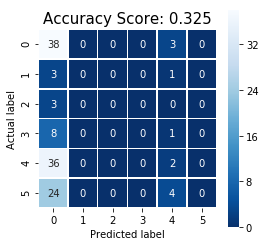

In [85]:
#optimized for accuracy
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
exported_pipeline = make_pipeline(
    SelectPercentile(score_func=f_classif, percentile=20),
    KNeighborsClassifier(n_neighbors=59, p=2, weights="uniform")
)

exported_pipeline.fit(x_train, y_train['Assigned Segment'])
predictions = exported_pipeline.predict(x_test)

score = exported_pipeline.score(x_test, y_test['Assigned Segment'])
cm = metrics.confusion_matrix(y_test['Assigned Segment'], predictions)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

### 2. Baseline: Predicting answers to 10 questions, then using Bain Segmentation Key

In [66]:
questions = [
    'I always choose higher end hotels',
    'On vacation I pride myself on discovering new places and things my friends have not seen before',
    'I choose more expensive hotels and accommodations to make sure I get the best service and amenities',
    'It is important for me to be in a luxurious setting and to be pampered on vacation',
    'I like to immerse myself in the local culture when on vacation',
    'The difference between luxury and standard hotels just is not big enough to justify the cost',
    'I always pay more for a higher class of room on my vacations',
    'I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation',
    'I think spending more for unique experiences is part of what makes a vacation special',
    'I like to go on vacations that are off the beaten path'
]

I always choose higher end hotels


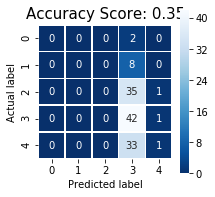

On vacation I pride myself on discovering new places and things my friends have not seen before


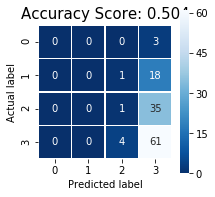

I choose more expensive hotels and accommodations to make sure I get the best service and amenities


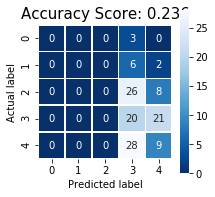

It is important for me to be in a luxurious setting and to be pampered on vacation


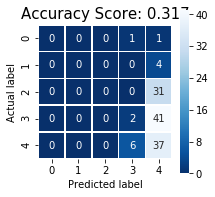

I like to immerse myself in the local culture when on vacation


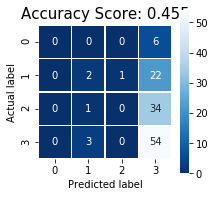

The difference between luxury and standard hotels just is not big enough to justify the cost


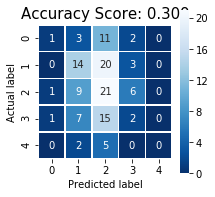

I always pay more for a higher class of room on my vacations


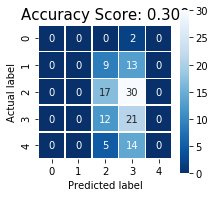

I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation


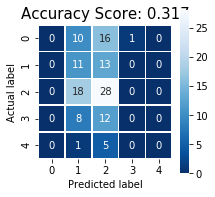

I think spending more for unique experiences is part of what makes a vacation special


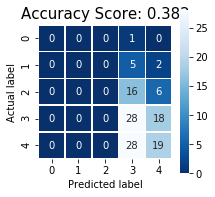

I like to go on vacations that are off the beaten path


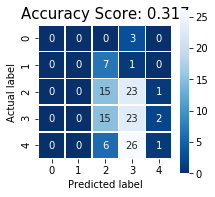

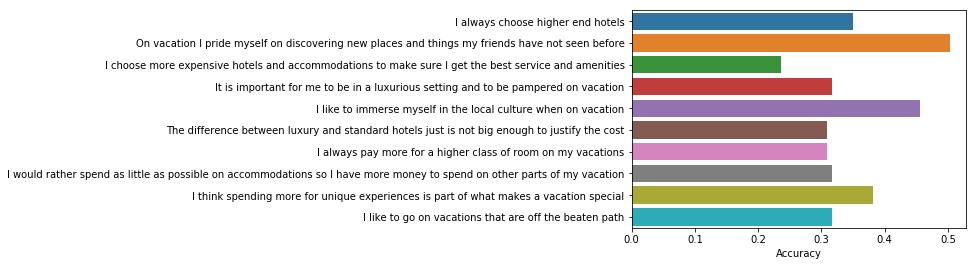

In [67]:
#make predictions for each question, store probability for every class (1-5)

#storage lists:
question_test_preds = []
question_test_pred_probas = []
question_train_pred_probas = []
question_test_scores = []

#loop through questions and make predictions, output results
for i in questions:
    #model
    # all parameters not specified are set to their defaults
    logisticRegr = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial')
    logisticRegr.fit(x_train, y_train[i])
    test_predictions = logisticRegr.predict(x_test)
    train_prediction_probas = logisticRegr.predict_proba(x_train)
    test_prediction_probas = logisticRegr.predict_proba(x_test)
    # Use score method to get accuracy of model
    test_score = logisticRegr.score(x_test, y_test[i])
    
    #append
    question_test_preds.append(test_predictions)
    question_test_scores.append(test_score)
    
    question_test_pred_probas.append(test_prediction_probas)
    question_train_pred_probas.append(train_prediction_probas)
    
    #print results
    print(i)
    cm = metrics.confusion_matrix(y_test[i], test_predictions)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');
    all_sample_title = 'Accuracy Score: {0}'.format(test_score.round(3))
    plt.title(all_sample_title, size = 15)
    plt.show()

#Final accuracy by question
sns.barplot(y = questions, x = question_test_scores).set(xlabel='Accuracy');

In [69]:
def proba_enricher(df, probas):
    df_enrich = df.reset_index().copy().iloc[:,1:]

    #append training and test sets
    add = "Q1_"
    for i in range(len(questions)):
        add = "Q" + str(i + 1) + "_" 
        probas_df = pd.DataFrame(probas[i], columns = [add + i for i in ["one","two","three","four","five"]])
        df_enrich = pd.concat([df_enrich, probas_df], axis = 1)
    
    return df_enrich

In [70]:
#train
x_train_enrich = proba_enricher(x_train, question_train_pred_probas)

#test
x_test_enrich = proba_enricher(x_test, question_test_pred_probas)
x_test_enrich.head()

,person_basicdemographics_age,person_basicdemographics_deceased,person_basicdemographics_enteringadulthood,person_basicdemographics_lengthofresidence,person_basicdemographics_singleparent,household_basicdemographics_africanamericanprofessionals,household_basicdemographics_childnearhsgraduation,household_basicdemographics_childrenpresent,household_basicdemographics_estimatedincomemin,household_basicdemographics_estimatedincomemax,...,Q9_one,Q9_two,Q9_three,Q9_four,Q9_five,Q10_one,Q10_two,Q10_three,Q10_four,Q10_five
0,44.0,False,False,0.0,False,False,False,False,0.0,14999.0,...,0.033844,0.091844,0.104146,0.401454,0.368713,0.009662,0.119974,0.311090,0.314097,0.245176
1,36.0,False,False,12.0,False,False,False,True,75000.0,99999.0,...,0.020613,0.027960,0.183551,0.402664,0.365212,0.009974,0.092686,0.328397,0.331789,0.237154
2,54.0,False,False,0.0,False,False,False,True,125000.0,0.0,...,0.013462,0.028552,0.250825,0.320123,0.387038,0.028064,0.108929,0.342493,0.277166,0.243348
3,28.0,False,False,15.0,False,False,False,True,50000.0,74999.0,...,0.026158,0.040895,0.207392,0.308168,0.417388,0.008343,0.093439,0.309378,0.229398,0.359442
4,48.0,False,False,12.0,False,False,False,False,40000.0,49999.0,...,0.025913,0.051754,0.136879,0.413126,0.372327,0.010649,0.106641,0.318835,0.334180,0.229694


#### 2a. Using probas as features, and using model to predict segment

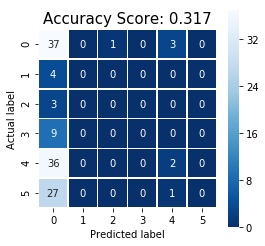

In [71]:
#model
# all parameters not specified are set to their defaults
logisticRegr = LogisticRegression(random_state=0)
logisticRegr.fit(x_train_enrich, y_train['Assigned Segment'])
predictions = logisticRegr.predict(x_test_enrich)
# Use score method to get accuracy of model
score = logisticRegr.score(x_test_enrich, y_test['Assigned Segment'])

cm = metrics.confusion_matrix(y_test['Assigned Segment'], predictions)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

#### 2b. Using predicted answer to questions in Bain Segmentation Key

In [73]:
#load .py file
import sys
sys.path.append('../../progs/')
import bain_response_enrich as bre
def list_array_todf(list_array, column_names):
    df = list_array.copy()
    for i in range(len(list_array)):
        df[i] = list_array[i].tolist()
    df = pd.DataFrame(df).T
    df.columns = column_names
    return df

question_test_preds_df = list_array_todf(question_test_preds, questions)
question_test_preds_df.head()

,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path
0,4,5,4,5,5,4,4,3,4,4
1,4,5,4,5,5,3,3,2,4,4
2,4,5,5,5,5,2,3,2,5,3
3,4,5,4,4,5,3,3,2,5,5
4,4,5,4,5,5,3,4,3,4,4


In [74]:
question_test_preds_df_assigned = bre.bain_response_enrich(question_test_preds_df)
question_test_preds_df_assigned.head()

,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,Assigned Segment,Assigned Segment (Model Value),Cheap + Comfy,Cheap + Curious,Curious,Comfy,Craver,Caviar
0,4,5,4,5,5,4,4,3,4,4,Craver,101.931,81.903,80.278,94.812,93.833,101.931,97.778
1,4,5,4,5,5,3,3,2,4,4,Craver,89.712,72.341,70.420,84.939,83.591,89.712,88.180
2,4,5,5,5,5,2,3,2,5,3,Caviar,93.725,72.385,69.589,86.905,86.271,93.446,93.725
3,4,5,4,4,5,3,3,2,5,5,Craver,91.674,75.520,76.267,89.208,85.449,91.674,89.687
4,4,5,4,5,5,3,4,3,4,4,Craver,97.804,77.559,75.702,90.965,90.132,97.804,94.963


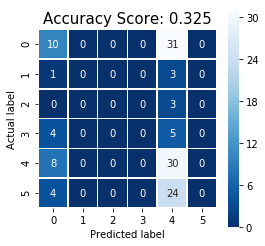

In [75]:
score = np.mean(y_test.reset_index(drop=True)['Assigned Segment'] == question_test_preds_df_assigned.reset_index(drop=True)['Assigned Segment'])
cm = metrics.confusion_matrix(y_test['Assigned Segment'], question_test_preds_df_assigned['Assigned Segment'])
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

#### 2c. Using MultiOutputRegressor to predict all dependent variables at once (including Assigned Segment)

In [76]:
#Convert 'Assigend Segment' to dummies for muli-regressor
def add_dummies(df, column):
    df_dummies = pd.get_dummies(df[column])
    df_dummies = pd.concat([df_dummies, df], axis = 1).drop([column], axis = 1)
    return df_dummies

y_train_dummies = add_dummies(y_train, 'Assigned Segment')
y_test_dummies = add_dummies(y_test, 'Assigned Segment')
y_test_dummies.head()

,Caviar,Cheap + Comfy,Cheap + Curious,Comfy,Craver,Curious,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,...,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,Cheap + Comfy,Cheap + Curious,Curious,Comfy,Craver,Caviar
579,0,0,0,0,0,1,3,4,3,3,...,3,3,4,5,63.99,64.75,71.59,68.27,68.03,66.28
52,0,0,0,1,0,0,3,4,4,5,...,3,4,3,3,59.67,52.84,64.88,68.13,67.85,66.71
534,0,0,0,1,0,0,3,3,3,4,...,3,1,4,4,52.94,46.35,56.32,58.34,54.64,56.12
348,0,0,0,0,0,1,4,4,3,4,...,2,4,4,4,64.97,62.99,71.68,70.64,71.42,68.53
55,0,0,0,1,0,0,4,3,2,3,...,3,3,1,3,37.03,26.36,34.55,39.97,30.44,32.96


In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor

max_depth = 30
regr_multirf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                          max_depth=max_depth,
                                                          random_state=0))
regr_multirf.fit(x_train, y_train_dummies)

regr_rf = RandomForestRegressor(n_estimators=100, max_depth=max_depth,
                                random_state=2)
regr_rf.fit(x_train, y_train_dummies)

# Predict on new data
y_multirf = regr_multirf.predict(x_test)
y_rf = regr_rf.predict(x_test)